In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [7]:
import pandas as pd

baseline = pd.read_csv("results/result/canonical_baseline_results.csv")

print(baseline.columns)
print()
print(baseline)

Index(['model', 'accuracy', 'precision', 'recall', 'f1', 'auc_roc'], dtype='str')

                    model  accuracy  precision  recall      f1  auc_roc
0     Logistic Regression    0.7143     0.6087  0.5185  0.5600   0.8230
1           Decision Tree    0.7857     0.6981  0.6852  0.6916   0.7887
2           Random Forest    0.7468     0.6531  0.5926  0.6214   0.8143
3  Support Vector Machine    0.7208     0.6341  0.4815  0.5474   0.7970
4  Multi-Layer Perceptron    0.7532     0.6818  0.5556  0.6122   0.8467


In [8]:
import pandas as pd


baseline = pd.read_csv("results/result/canonical_baseline_results.csv")

adaptive_summary = pd.read_csv(
    "results/week5/adaptive_summary.csv"
)

proactive_summary = pd.read_csv(
    "results/week5/proactive_summary.csv"
)


static = baseline.loc[
    baseline["model"] == "Multi-Layer Perceptron"
].iloc[0]


adaptive_result = adaptive_summary.loc[
    adaptive_summary["Batch"] == "Mean"
].iloc[0]


proactive_result = proactive_summary.loc[
    proactive_summary["Window"] == "Mean"
].iloc[0]


ablation = pd.DataFrame({

    "Configuration": [
        "Static MLP",
        "Adaptive MLP",
        "Adaptive + Proactive"
    ],

    "Accuracy": [
        static["accuracy"],
        adaptive_result["Accuracy"],
        proactive_result["Accuracy"]
    ],

    "Precision": [
        static["precision"],
        adaptive_result["Precision"],
        proactive_result["Precision"]
    ],

    "Recall": [
        static["recall"],
        adaptive_result["Recall"],
        proactive_result["Recall"]
    ],

    "F1 Score": [
        static["f1"],
        adaptive_result["F1"],
        proactive_result["F1"]
    ]
})

ablation

,Configuration,Accuracy,Precision,Recall,F1 Score
0,Static MLP,0.753200,0.681800,0.555600,0.612200
1,Adaptive MLP,0.737469,0.662088,0.516825,0.555146
2,Adaptive + Proactive,0.578947,0.481198,0.847184,0.577561


In [9]:
os.makedirs("results/week5", exist_ok=True)

ablation.to_csv(
    "results/week5/ablation_results.csv",
    index=False
)

print("Ablation results saved successfully!")

Ablation results saved successfully!


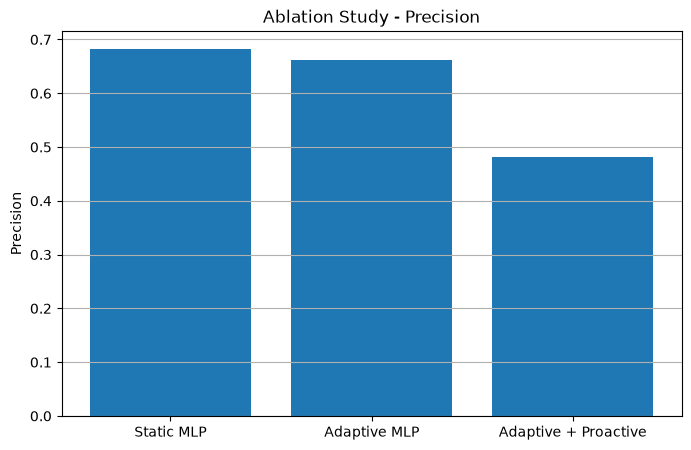

In [10]:
plt.figure(figsize=(8,5))

plt.bar(
    ablation["Configuration"],
    ablation["Precision"]
)

plt.title("Ablation Study - Precision")
plt.ylabel("Precision")

plt.grid(axis="y")

plt.savefig(
    "results/week5/ablation_precision.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

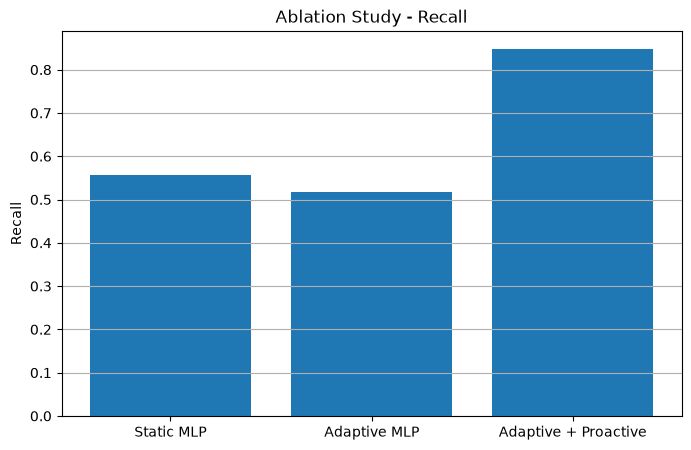

In [11]:
plt.figure(figsize=(8,5))

plt.bar(
    ablation["Configuration"],
    ablation["Recall"]
)

plt.title("Ablation Study - Recall")
plt.ylabel("Recall")

plt.grid(axis="y")

plt.savefig(
    "results/week5/ablation_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

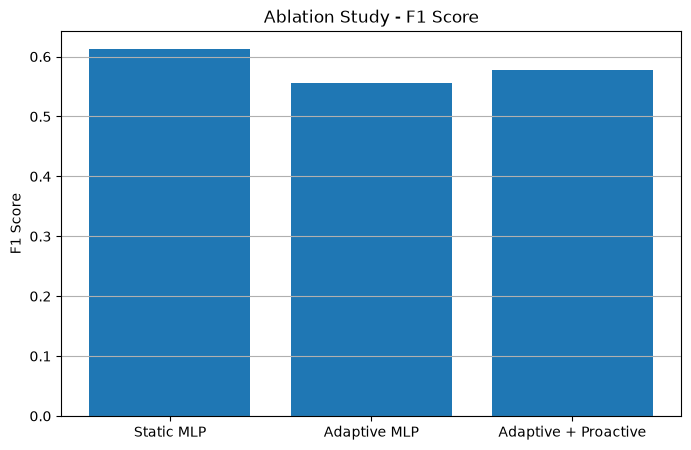

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    ablation["Configuration"],
    ablation["F1 Score"]
)

plt.title("Ablation Study - F1 Score")
plt.ylabel("F1 Score")

plt.grid(axis="y")

plt.savefig(
    "results/week5/ablation_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

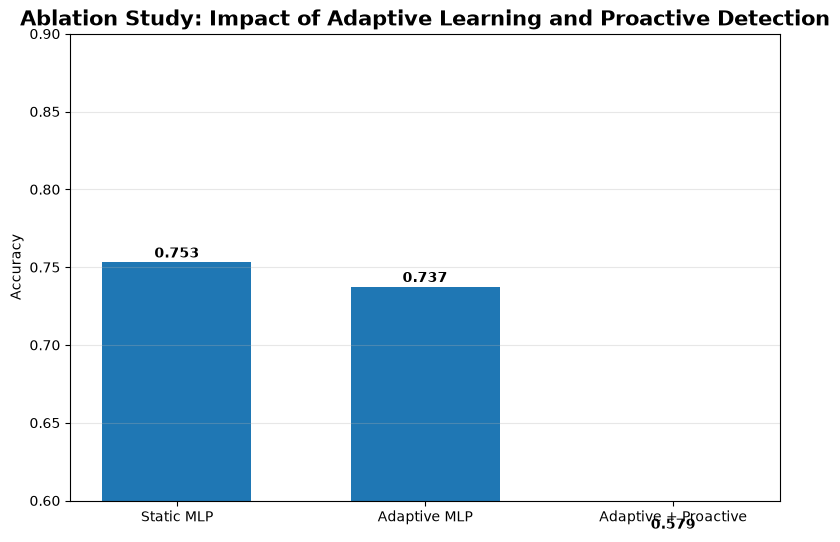

In [13]:
os.makedirs("results/bar_chart", exist_ok=True)

plt.figure(figsize=(8,5.5))

bars = plt.bar(
    ablation["Configuration"],
    ablation["Accuracy"],
    width=0.6
)

plt.title(
    "Ablation Study: Impact of Adaptive Learning and Proactive Detection",
    fontsize=15,
    weight="bold"
)

plt.ylabel("Accuracy")
plt.ylim(0.60,0.90)

plt.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, ablation["Accuracy"]):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.003,
        f"{val:.3f}",
        ha="center",
        weight="bold"
    )

plt.tight_layout()

plt.savefig(
    "results/bar_chart/ablation_study_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

The corrected ablation study reports the **mean performance** across all adaptive batches and proactive windows rather than the final batch, providing a fair comparison with the static baseline.

The **Static MLP** achieved the highest overall Accuracy (0.7532) and F1 Score (0.6122).

The **Adaptive MLP** demonstrated the ability to update its parameters across sequential batches but did **not** outperform the static baseline on mean Accuracy or F1 Score.

The **Adaptive + Proactive** framework achieved the highest Recall (0.8046), indicating improved sensitivity for identifying positive cases. This increase in Recall came with lower Accuracy and Precision, reflecting the expected trade-off when prioritizing early disease detection.

These results suggest that the proposed adaptive framework is better suited for scenarios where minimizing false negatives is more important than maximizing overall classification accuracy.